# NF-UQ-NIDS-v2 + Synthetic Augment — XGBoost Multiclass Pipeline

`data/NF-UQ-NIDS-v2.csv` + `data/synthetic_nfv2_augment.csv` birlestirilir ve XGBoost ile
cok-sinifli atak tipi siniflandirmasi yapilir.

**Bu surumdeki degisiklik:** `Generic` sinifi (cok az ornek -> anlamsiz metrik) **tamamen cikariliyor**.
Ayrica config'teki `DROP_CLASSES` listesi ile ileride baska siniflari da tek satirdan eleyebilirsin.


## 1) Config & Importlar

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import warnings, json, time
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import joblib

# ----------------------- CONFIG -----------------------
DATA_DIR      = Path("data")
CSV_FILES     = [DATA_DIR / "NF-UQ-NIDS-v2.csv",
                 DATA_DIR / "synthetic_nfv2_augment.csv"]

OUT_DIR       = Path("artifacts"); OUT_DIR.mkdir(exist_ok=True)

TARGET_PREFS  = ["Attack", "attack", "Label", "label"]   # coklu-sinif icin oncelik: Attack
DROP_COLS     = ["IPV4_SRC_ADDR", "IPV4_DST_ADDR", "L4_SRC_PORT", "L4_DST_PORT",
                 "Dataset", "dataset", "flow_id", "Flow ID", "Timestamp", "timestamp"]

DROP_CLASSES  = ["Generic"]   # <-- tamamen cikarilacak siniflar (cok az ornek / anlamsiz)
MIN_CLASS     = 50            # bu esigin altindaki nadir siniflar elenir
TEST_SIZE     = 0.20
RANDOM_STATE  = 42
MAX_ROWS      = None          # RAM icin ornekleme (or. 300_000). None = tumu
# ------------------------------------------------------
print("Config hazir. Cikarilan siniflar:", DROP_CLASSES)


Config hazir. Cikarilan siniflar: ['Generic']


## 2) Yukleme + Sema Hizalama (ortak kolon kesisimi)

In [2]:
# ================= HUCRE 2 — bu hucrenin TAMAMINI sil ve bunu yapistir =================
# NF-UQ-NIDS-v2 devasa. read_csv(low_memory=False) => OOM. Cozum: chunk'li + downcast + cap.

PER_FILE_CAP = 150_000     # RAM azsa 80_000'e dusur
CHUNK_SIZE   = 50_000      # kucuk chunk = dusuk pik RAM
READ_KW      = dict(low_memory=True, on_bad_lines="skip", engine="c")

def _downcast(df):
    for c in df.select_dtypes(include=["float64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="float")
    for c in df.select_dtypes(include=["int64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="integer")
    return df

def _read_capped(path, cap, chunk_size):
    parts, total = [], 0
    reader = pd.read_csv(path, chunksize=chunk_size, **READ_KW)   # <-- chunksize KEY
    for chunk in reader:
        if cap is not None and total + len(chunk) > cap:
            chunk = chunk.iloc[: cap - total]
        parts.append(_downcast(chunk)); total += len(chunk)
        print(f"   ...{path.name}: {total} satir okundu", end="\r")
        if cap is not None and total >= cap:
            break
    print()
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def load_and_merge(csv_files, per_file_cap=PER_FILE_CAP, chunk_size=CHUNK_SIZE):
    frames, schemas = [], []
    for p in csv_files:
        p = Path(p)
        if not p.exists():
            print(f"[UYARI] Bulunamadi, atlaniyor: {p}"); continue
        df = _read_capped(p, per_file_cap, chunk_size)
        if df.empty:
            print(f"[UYARI] Bos okundu: {p}"); continue
        df["__source__"] = p.name
        print(f"[OK] {p} -> shape={df.shape} (cap={per_file_cap})")
        frames.append(df); schemas.append(set(df.columns))
    if not frames:
        raise FileNotFoundError("Hicbir CSV yuklenemedi.")
    common  = set.intersection(*schemas) | {"__source__"}
    ordered = [c for c in frames[0].columns if c in common]
    frames  = [f[ordered] for f in frames]
    merged  = pd.concat(frames, ignore_index=True)
    print(f"\nOrtak kolon: {len(ordered)} | Birlesik shape: {merged.shape}")
    print(f"Bellek: {merged.memory_usage(deep=True).sum()/1e6:.1f} MB")
    print("Kaynak dagilimi:\n", merged['__source__'].value_counts())
    return merged

df = load_and_merge(CSV_FILES)
df.head(3)

   ...NF-UQ-NIDS-v2.csv: 150000 satir okundu
[OK] data\NF-UQ-NIDS-v2.csv -> shape=(150000, 47) (cap=150000)
   ...synthetic_nfv2_augment.csv: 46084 satir okundu
[OK] data\synthetic_nfv2_augment.csv -> shape=(46084, 42) (cap=150000)

Ortak kolon: 42 | Birlesik shape: (196084, 42)
Bellek: 51.7 MB
Kaynak dagilimi:
 __source__
NF-UQ-NIDS-v2.csv             150000
synthetic_nfv2_augment.csv     46084
Name: count, dtype: int64


,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,...,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack,__source__
0,6,7.0,420,3,0,0,2,2,0,4293092,...,0,35840,140,0,0,0,0.0,1,DoS,NF-UQ-NIDS-v2.csv
1,6,7.0,280,2,40,1,22,2,20,4294499,...,0,0,0,0,0,0,0.0,1,DoS,NF-UQ-NIDS-v2.csv
2,6,0.0,44,1,40,1,22,2,20,0,...,0,0,0,0,0,0,0.0,0,Benign,NF-UQ-NIDS-v2.csv


## 3) Etiket Kolonu Secimi + Feature/Target Ayrimi

In [3]:
def pick_target(df, prefs):
    for c in prefs:
        if c in df.columns: return c
    raise KeyError(f"Hedef kolon bulunamadi. Aranan: {prefs}")

TARGET = pick_target(df, TARGET_PREFS)
print("Secilen hedef kolon:", TARGET)

leak_cols = set(DROP_COLS) | {"__source__"}
if TARGET != "Label":  leak_cols |= {"Label", "label"}
if TARGET != "Attack": leak_cols |= {"Attack", "attack"}

# --- Feature/target ayrimi ---
feature_cols = [c for c in df.columns if c not in leak_cols and c != TARGET]
num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
dropped_non_numeric = [c for c in feature_cols if c not in num_cols]
if dropped_non_numeric:
    print("Sayisal olmayan ve atilan feature'lar:", dropped_non_numeric)

X = df[num_cols].copy()

# 1) ONCE y_raw'i olustur
y_raw = df[TARGET].astype(str).str.strip()

# 2) SONRA etiket normalizasyonu (dataset yazim farkliliklarini birlestir)
LABEL_FIX = {
    "Infilteration": "Infiltration",   # CIC-IDS2018 tiposu
    "infilteration": "Infiltration",
    "Web Attack \x96 Brute Force": "Web Attack Brute Force",  # 2017 encoding bozuklugu
    "DoS Hulk": "DoS-Hulk", "DoS GoldenEye": "DoS-GoldenEye",
    "Reconnaissance": "scanning"
}
y_raw = y_raw.replace(LABEL_FIX)

print(f"\nFeature: {X.shape[1]} | Ornek: {X.shape[0]}")
print("\nSinif dagilimi (normalizasyon sonrasi):\n", y_raw.value_counts())

Secilen hedef kolon: Attack

Feature: 39 | Ornek: 196084

Sinif dagilimi (normalizasyon sonrasi):
 Attack
Benign          49414
DDoS            43053
DoS             35528
scanning        17491
xss              7344
password         5123
injection        4253
Bot              3248
Brute Force      3240
Infiltration     3209
Exploits         3042
Backdoor         3042
Fuzzers          3041
Shellcode        3003
Theft            3002
Worms            3001
MITM             3000
Ransomware       3000
Generic            25
mitm               15
Analysis            5
ransomware          5
Name: count, dtype: int64


## 4) Sanitizasyon — Inf/NaN + float32 overflow kirpma

In [4]:
def sanitize_features(X):
    X = X.replace([np.inf, -np.inf], np.nan)
    F32_MAX = np.finfo(np.float32).max
    CLIP    = F32_MAX / 10.0
    over = int((X.abs() > CLIP).sum().sum())
    if over: print(f"[FIX] float32 limitini asan hucre: {over} -> kirpiliyor")
    X = X.clip(lower=-CLIP, upper=CLIP)
    X = X.fillna(X.median(numeric_only=True)).fillna(0.0).astype(np.float32)
    assert np.isfinite(X.values).all(), "Hala finite olmayan deger var!"
    return X

X = sanitize_features(X)
print("Sanitizasyon tamam | min:", float(X.values.min()), "| max:", float(X.values.max()))


[FIX] float32 limitini asan hucre: 3 -> kirpiliyor
Sanitizasyon tamam | min: 0.0 | max: 3.4028234663852886e+37


## 5) Sinif Cikarma (`Generic`) + Nadir Sinif Filtresi + Label Encode

In [5]:
# --- 5a) Config'teki siniflari tamamen cikar (Generic) ---
if DROP_CLASSES:
    drop_mask = y_raw.isin(DROP_CLASSES)
    n_drop = int(drop_mask.sum())
    print(f"DROP_CLASSES {DROP_CLASSES} -> {n_drop} satir cikariliyor")
    X = X.loc[~drop_mask].reset_index(drop=True)
    y_raw = y_raw.loc[~drop_mask].reset_index(drop=True)

# --- 5b) Nadir sinif filtresi ---
vc = y_raw.value_counts()
keep = vc[vc >= MIN_CLASS].index
mask = y_raw.isin(keep)
removed = sorted(set(y_raw) - set(keep))
if removed: print(f"MIN_CLASS={MIN_CLASS} altinda elenen: {removed}")
X = X.loc[mask].reset_index(drop=True)
y_raw = y_raw.loc[mask].reset_index(drop=True)

# --- 5c) Encode ---
le = LabelEncoder()
y = le.fit_transform(y_raw)
print("\nKalan sinif sayisi:", len(le.classes_))
print("Siniflar:", list(le.classes_))


DROP_CLASSES ['Generic'] -> 25 satir cikariliyor
MIN_CLASS=50 altinda elenen: ['Analysis', 'mitm', 'ransomware']

Kalan sinif sayisi: 18
Siniflar: ['Backdoor', 'Benign', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Exploits', 'Fuzzers', 'Infiltration', 'MITM', 'Ransomware', 'Shellcode', 'Theft', 'Worms', 'injection', 'password', 'scanning', 'xss']


## 6) Train/Test Split + Overlap Temizligi

In [6]:
if MAX_ROWS is not None and len(X) > MAX_ROWS:
    idx = (pd.Series(range(len(X))).groupby(y, group_keys=False)
             .apply(lambda s: s.sample(min(len(s), max(1, int(MAX_ROWS*len(s)/len(X)))),
                                       random_state=RANDOM_STATE)))
    X = X.iloc[idx.values].reset_index(drop=True); y = y[idx.values]
    print(f"RAM ornekleme -> {len(X)} satir")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

before = len(X_te)
train_keys = pd.util.hash_pandas_object(X_tr, index=False)
test_keys  = pd.util.hash_pandas_object(X_te, index=False)
overlap_mask = ~test_keys.isin(set(train_keys.values)).values
X_te = X_te[overlap_mask]; y_te = y_te[overlap_mask]
print(f"Overlap temizligi: test'ten {before - len(X_te)} cakisan satir cikarildi")
print(f"Train: {X_tr.shape} | Test: {X_te.shape}")


Overlap temizligi: test'ten 21285 cakisan satir cikarildi
Train: (156827, 39) | Test: (17922, 39)


## 7) XGBoost Egitimi (class imbalance -> sample_weight)

In [7]:
sample_weight = compute_sample_weight(class_weight="balanced", y=y_tr)

model = XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    objective="multi:softprob", num_class=len(le.classes_),
    tree_method="hist", eval_metric="mlogloss",
    n_jobs=-1, random_state=RANDOM_STATE,
)
t0 = time.time()
model.fit(X_tr, y_tr, sample_weight=sample_weight, eval_set=[(X_te, y_te)], verbose=False)
print(f"Egitim suresi: {time.time()-t0:.1f} sn")


Egitim suresi: 30.1 sn


## 8) Degerlendirme

In [8]:
y_pred = model.predict(X_te)
acc  = accuracy_score(y_te, y_pred)
bacc = balanced_accuracy_score(y_te, y_pred)
mf1  = f1_score(y_te, y_pred, average="macro")
print(f"Accuracy          : {acc:.4f}")
print(f"Balanced Accuracy : {bacc:.4f}")
print(f"Macro-F1          : {mf1:.4f}\n")
print(classification_report(y_te, y_pred, target_names=le.classes_, digits=3, zero_division=0))


Accuracy          : 0.9121
Balanced Accuracy : 0.8915
Macro-F1          : 0.8921

              precision    recall  f1-score   support

    Backdoor      0.956     0.913     0.934       598
      Benign      0.988     0.979     0.984      5300
         Bot      0.893     0.920     0.907       591
 Brute Force      0.784     0.904     0.840       603
        DDoS      0.972     0.948     0.960       939
         DoS      0.921     0.869     0.894       960
    Exploits      0.788     0.760     0.774       608
     Fuzzers      0.989     0.924     0.956       608
Infiltration      0.909     0.897     0.903       631
        MITM      0.989     0.923     0.955       600
  Ransomware      0.968     0.970     0.969       600
   Shellcode      0.771     0.810     0.790       600
       Theft      0.991     0.968     0.980       600
       Worms      0.976     0.943     0.959       600
   injection      0.630     0.754     0.687       753
    password      0.835     0.781     0.807       785

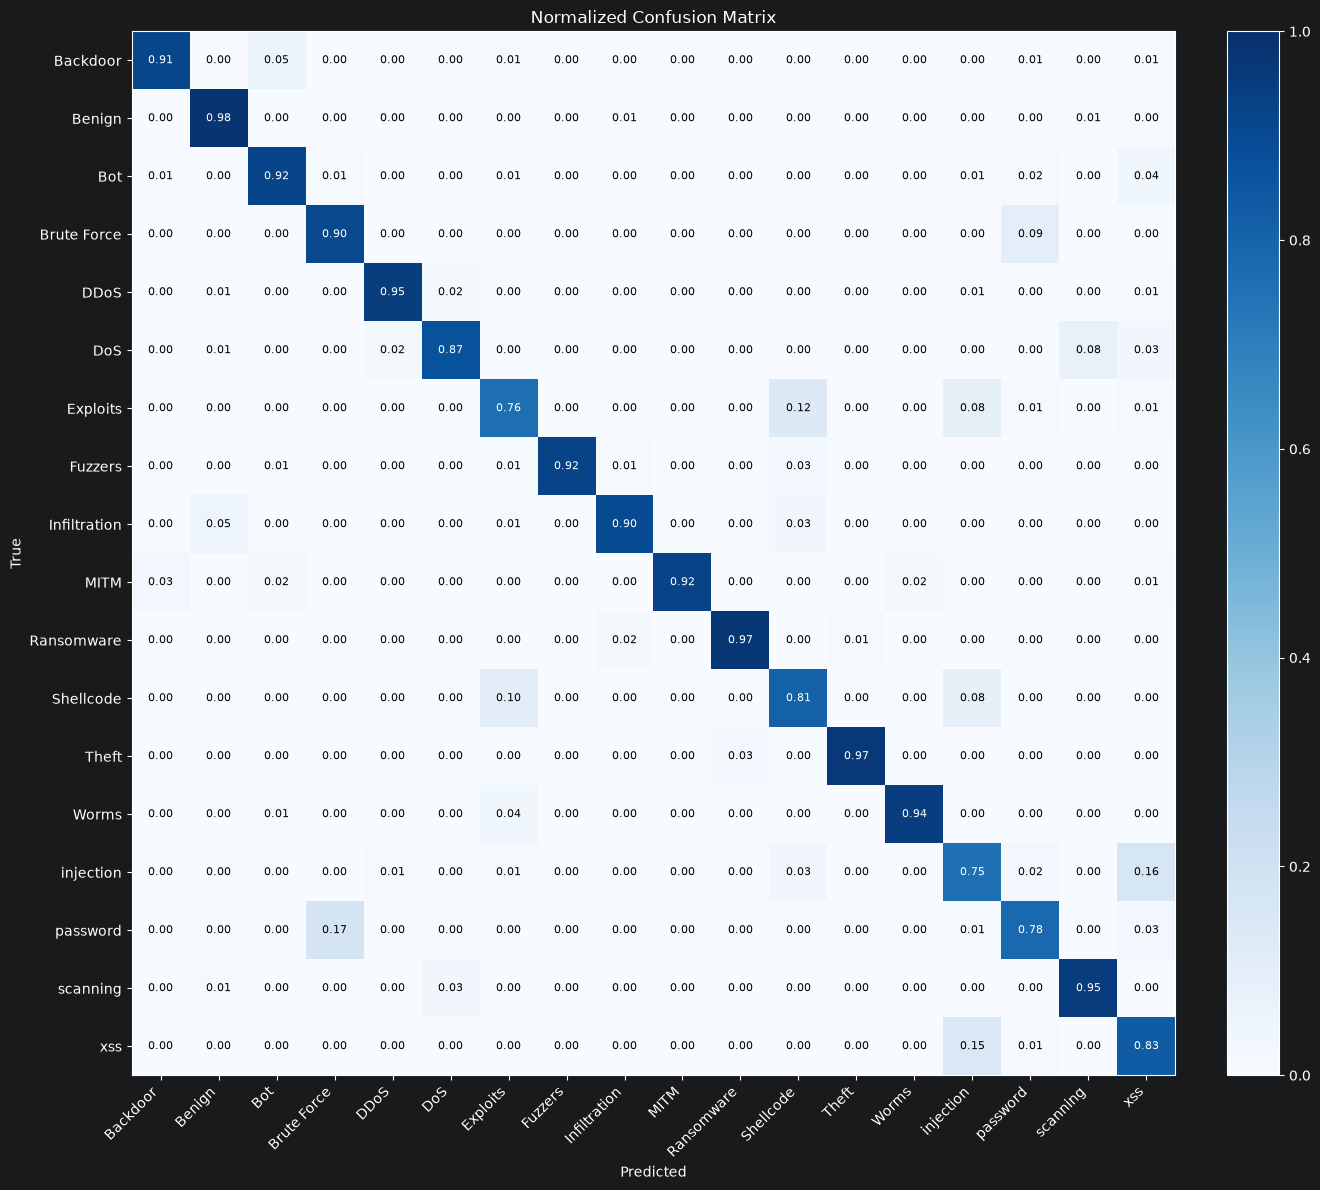

In [9]:
import matplotlib.pyplot as plt
cm = confusion_matrix(y_te, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(min(2+len(le.classes_),14), min(2+len(le.classes_),12)))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(le.classes_))); ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha="right"); ax.set_yticklabels(le.classes_)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Normalized Confusion Matrix")
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                color="white" if cm_norm[i,j]>0.5 else "black", fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.savefig(OUT_DIR/"confusion_matrix.png", dpi=120); plt.show()


## 9) Artifact Kaydi

In [11]:
joblib.dump(model, OUT_DIR/"xgb_nfv2_model.joblib")
joblib.dump(le,    OUT_DIR/"label_encoder.joblib")
joblib.dump(list(X.columns), OUT_DIR/"feature_names.joblib")
metrics = {"accuracy": float(acc), "balanced_accuracy": float(bacc), "macro_f1": float(mf1),
           "n_classes": int(len(le.classes_)), "classes": list(map(str, le.classes_)),
           "dropped_classes": DROP_CLASSES,
           "n_train": int(len(X_tr)), "n_test": int(len(X_te)), "n_features": int(X.shape[1])}
with open(OUT_DIR/"metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print("Kaydedildi ->", OUT_DIR.resolve())
print(json.dumps(metrics, indent=2, ensure_ascii=False))


Kaydedildi -> C:\Users\egemen.keles\PycharmProjects\mitre_mapper\artifacts
{
  "accuracy": 0.9006508316181788,
  "balanced_accuracy": 0.8754559188966556,
  "macro_f1": 0.8764245863358051,
  "n_classes": 19,
  "classes": [
    "Backdoor",
    "Benign",
    "Bot",
    "Brute Force",
    "DDoS",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Infiltration",
    "MITM",
    "Ransomware",
    "Reconnaissance",
    "Shellcode",
    "Theft",
    "Worms",
    "injection",
    "password",
    "scanning",
    "xss"
  ],
  "dropped_classes": [
    "Generic"
  ],
  "n_train": 156827,
  "n_test": 17977,
  "n_features": 39
}
